# 07 — Canonical pharmacometrics event semantics

Pharmacometric calculations depend on more than numeric columns: dose, observation, reset, covariate, and infusion-stop records have different meanings. This notebook converts plain Python records into PyMixEF's immutable, audited event table and makes expansion and same-time ordering explicit.

## Objectives

- Canonicalize dose, observation, covariate, and infusion records.
- Inspect deterministic subject/time/event ordering.
- Materialize ADDL/II doses and generated infusion stops.
- Trace generated rows to their source rows through the audit log.
- Distinguish a recorded zero dose, an explicitly unknown dose, and a non-applicable amount.

In [1]:
import importlib
import logging
from collections import Counter

import numpy as np

from pymixef.pharmacometrics import (
    EventValidationError,
    canonicalize_events,
)

# Keep a fresh-kernel run free of Matplotlib's one-time font-cache status message.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt = importlib.import_module("matplotlib.pyplot")

plt.style.use("tableau-colorblind10")

## Source records

Subject P01 receives a bolus plus two additional doses every 12 hours. Subject P02 receives a two-hour infusion whose rate is derived from amount and duration. Observations at the same time as a dose occur after the dose under PyMixEF's documented event priority.

In [2]:
source_records = [
    {
        "ID": "P01",
        "TIME": 0,
        "EVID": "dose",
        "AMT": 100,
        "CMT": "central",
        "ADDL": 2,
        "II": 12,
        "ROW_ID": "dose-p01",
    },
    {
        "ID": "P01",
        "TIME": 0,
        "EVID": 0,
        "DV": 4.8,
        "CMT": "central",
        "ROW_ID": "obs-p01-0",
    },
    {
        "ID": "P01",
        "TIME": 12,
        "EVID": "covariate",
        "COVARIATES": {"weight": 72},
        "ROW_ID": "wt-p01",
    },
    {
        "ID": "P01",
        "TIME": 24,
        "EVID": 0,
        "DV": 1.1,
        "CMT": "central",
        "ROW_ID": "obs-p01-24",
    },
    {
        "ID": "P02",
        "TIME": 0,
        "EVID": "dose",
        "AMT": 60,
        "DUR": 2,
        "CMT": "central",
        "ROW_ID": "inf-p02",
    },
    {
        "ID": "P02",
        "TIME": 0,
        "EVID": 0,
        "DV": 0,
        "CMT": "central",
        "ROW_ID": "obs-p02-0",
    },
    {
        "ID": "P02",
        "TIME": 3,
        "EVID": 0,
        "DV": 2.2,
        "CMT": "central",
        "ROW_ID": "obs-p02-3",
    },
]

In [3]:
events = canonicalize_events(source_records)
same_time_p01 = [event.kind for event in events if event.subject_id == "P01" and event.time == 0]
assert same_time_p01 == ["dose", "observation"]
print("Subjects:", events.subjects)
for event in events:
    print(
        event.subject_id,
        event.time,
        event.kind,
        "amount=",
        event.amount,
        "rate=",
        event.rate,
        "row=",
        event.row_id,
    )

Subjects: ('P01', 'P02')
P01 0.0 dose amount= 100.0 rate= None row= dose-p01
P01 0.0 observation amount= None rate= None row= obs-p01-0
P01 12.0 covariate amount= None rate= None row= wt-p01
P01 24.0 observation amount= None rate= None row= obs-p01-24
P02 0.0 infusion_start amount= 60.0 rate= 30.0 row= inf-p02
P02 0.0 observation amount= None rate= None row= obs-p02-0
P02 3.0 observation amount= None rate= None row= obs-p02-3


## Canonical subject timelines

A timeline makes event type, subject, and time visible at once. Small vertical offsets separate same-time event types while preserving their shared time coordinate.

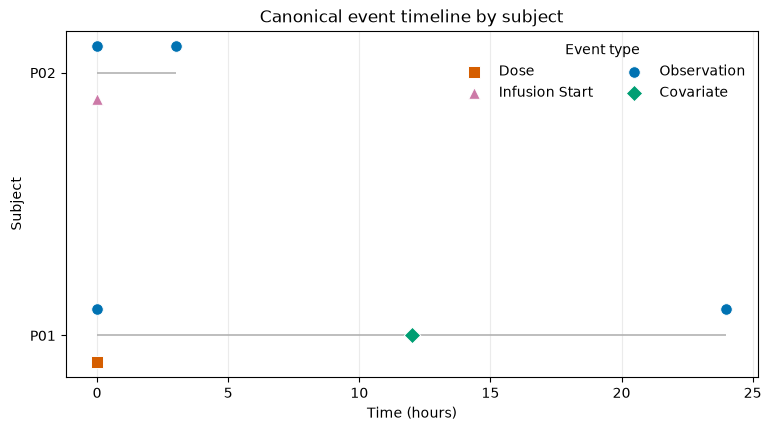

In [4]:
event_colors = {
    "dose": "#D55E00",
    "infusion_start": "#CC79A7",
    "observation": "#0072B2",
    "covariate": "#009E73",
}
event_markers = {
    "dose": "s",
    "infusion_start": "^",
    "observation": "o",
    "covariate": "D",
}
event_offsets = {
    "dose": -0.10,
    "infusion_start": -0.10,
    "observation": 0.10,
    "covariate": 0.0,
}
subject_positions = {subject: index for index, subject in enumerate(events.subjects)}

fig, ax = plt.subplots(figsize=(7.6, 4.2), constrained_layout=True)
for subject, position in subject_positions.items():
    subject_times = [event.time for event in events if event.subject_id == subject]
    ax.hlines(
        position,
        min(subject_times),
        max(subject_times),
        color="#B3B3B3",
        linewidth=1.2,
        zorder=1,
    )
for kind in event_colors:
    selected = [event for event in events if event.kind == kind]
    if not selected:
        continue
    ax.scatter(
        [event.time for event in selected],
        [subject_positions[event.subject_id] + event_offsets[kind] for event in selected],
        s=70,
        marker=event_markers[kind],
        color=event_colors[kind],
        edgecolor="white",
        linewidth=0.7,
        label=kind.replace("_", " ").title(),
        zorder=3,
    )
ax.set_yticks(list(subject_positions.values()), list(subject_positions))
ax.set(
    title="Canonical event timeline by subject",
    xlabel="Time (hours)",
    ylabel="Subject",
)
ax.legend(title="Event type", frameon=False, ncol=2)
ax.grid(axis="x", alpha=0.25)
plt.show()

**Interpretation.** The plot exposes both subjects' schedules and the dose/observation pairs at time zero. Canonical priority still determines computation order; the offsets are visual only and do not alter event time.

### Same-time rule

The complete priority is reset, covariate update, infusion stop, dose/infusion start, observation, then other. Source position is the final stable tie-breaker. Consequently, a same-time observation sees the post-dose state. The convention is explicit and must be checked against the intended analysis semantics.

## Expand derived events

Expansion returns a new event table; the source table is not modified. Generated rows retain `source_row_id` and receive deterministic row identifiers.

In [5]:
expanded = events.expand_additional().expand_infusions()
generated = [event for event in expanded if event.generated]
assert len(expanded) == 10 and len(generated) == 3
assert [event.kind for event in expanded if event.subject_id == "P01" and event.time == 24] == [
    "dose",
    "observation",
]
for event in expanded:
    print(
        event.subject_id,
        event.time,
        event.kind,
        "generated=",
        event.generated,
        "row=",
        event.row_id,
        "source=",
        event.source_row_id,
    )

print("\nOriginal rows:", len(events), "Expanded rows:", len(expanded))
print("Expansion and same-time ordering checks: passed")

P01 0.0 dose generated= False row= dose-p01 source= dose-p01
P01 0.0 observation generated= False row= obs-p01-0 source= obs-p01-0
P01 12.0 covariate generated= False row= wt-p01 source= wt-p01
P01 12.0 dose generated= True row= dose-p01:addl:1 source= dose-p01
P01 24.0 dose generated= True row= dose-p01:addl:2 source= dose-p01
P01 24.0 observation generated= False row= obs-p01-24 source= obs-p01-24
P02 0.0 infusion_start generated= False row= inf-p02 source= inf-p02
P02 0.0 observation generated= False row= obs-p02-0 source= obs-p02-0
P02 2.0 infusion_stop generated= True row= inf-p02:infusion-stop source= inf-p02
P02 3.0 observation generated= False row= obs-p02-3 source= obs-p02-3

Original rows: 7 Expanded rows: 10
Expansion and same-time ordering checks: passed


## Source and generated events

Expansion materializes scheduled ADDL doses and a finite-infusion stop. Faceting by subject and separating source from generated rows makes those additions easy to review.

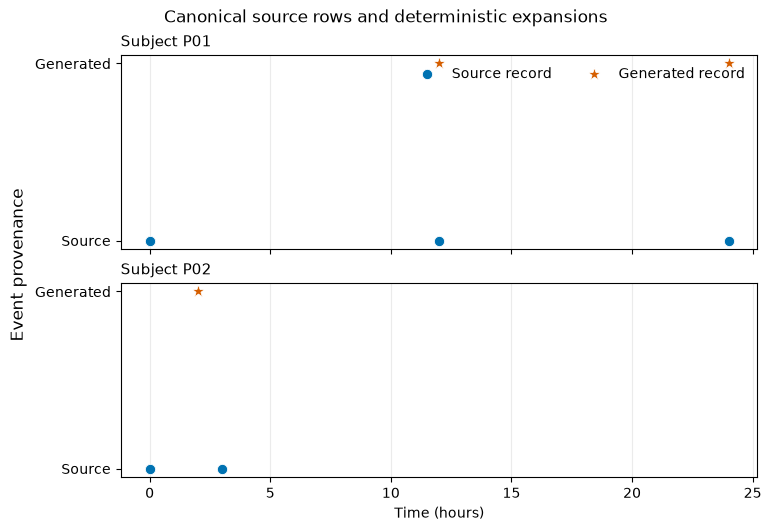

In [6]:
fig, axes = plt.subplots(
    len(expanded.subjects),
    1,
    figsize=(7.6, 5.2),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)
for ax, subject in zip(axes, expanded.subjects, strict=True):
    subject_events = list(expanded.for_subject(subject))
    for generated_status, label, marker, color in (
        (False, "Source record", "o", "#0072B2"),
        (True, "Generated record", "*", "#D55E00"),
    ):
        selected = [event for event in subject_events if event.generated == generated_status]
        ax.scatter(
            [event.time for event in selected],
            [int(generated_status)] * len(selected),
            s=95 if generated_status else 55,
            marker=marker,
            color=color,
            edgecolor="white",
            linewidth=0.6,
            label=label,
            zorder=3,
        )
    ax.set_yticks([0, 1], ["Source", "Generated"])
    ax.set_title(f"Subject {subject}", loc="left", fontsize=11)
    ax.grid(axis="x", alpha=0.25)
axes[0].legend(frameon=False, ncol=2, loc="upper right")
axes[-1].set_xlabel("Time (hours)")
fig.supylabel("Event provenance")
fig.suptitle("Canonical source rows and deterministic expansions")
plt.show()

**Interpretation.** P01 gains scheduled doses at 12 and 24 hours; P02 gains the infusion stop at 2 hours. Every generated point retains a source-row link in the audit table.

## Audit provenance

Audit codes record canonicalization, derived rate, ADDL expansion, and infusion-stop generation. This is more reliable than inferring transformations from row counts.

In [7]:
audit_counts = Counter(entry.code for entry in expanded.audit)
assert audit_counts["EVENT-ADDL-EXPANDED-001"] == 2
assert audit_counts["EVENT-INFUSION-EXPANDED-001"] == 1
print(audit_counts)

generated_audit = [
    entry.to_dict()
    for entry in expanded.audit
    if entry.code in {"EVENT-ADDL-EXPANDED-001", "EVENT-INFUSION-EXPANDED-001"}
]
generated_audit

Counter({'EVENT-CANONICALIZED-001': 7, 'EVENT-ADDL-EXPANDED-001': 2, 'EVENT-RATE-DERIVED-001': 1, 'EVENT-INFUSION-EXPANDED-001': 1})


[{'code': 'EVENT-ADDL-EXPANDED-001',
  'action': 'generated_additional_dose',
  'row_id': 'dose-p01:addl:1',
  'source_row_id': 'dose-p01',
  'details': {'dose_number': 1, 'time': 12.0, 'interval': 12.0}},
 {'code': 'EVENT-ADDL-EXPANDED-001',
  'action': 'generated_additional_dose',
  'row_id': 'dose-p01:addl:2',
  'source_row_id': 'dose-p01',
  'details': {'dose_number': 2, 'time': 24.0, 'interval': 12.0}},
 {'code': 'EVENT-INFUSION-EXPANDED-001',
  'action': 'generated_infusion_stop',
  'row_id': 'inf-p02:infusion-stop',
  'source_row_id': 'inf-p02',
  'details': {'time': 2.0, 'rate': 30.0}}]

## Audit action profile

Counting machine-readable audit codes summarizes how the canonical table was constructed without relying on manual row comparison.

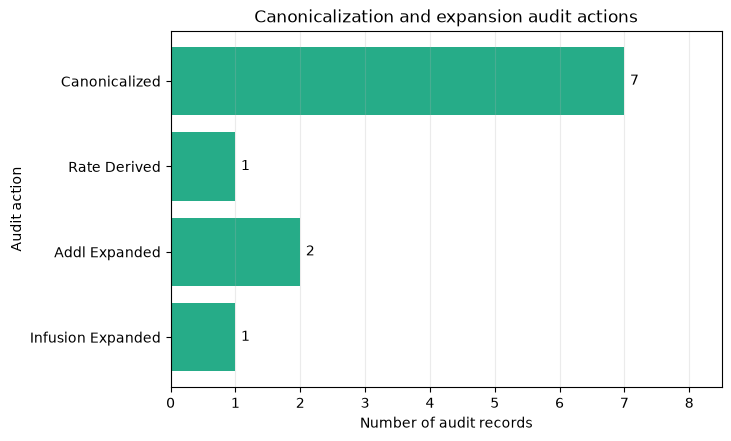

In [8]:
audit_labels = [
    code.removeprefix("EVENT-").removesuffix("-001").replace("-", " ").title()
    for code in audit_counts
]
audit_values = np.asarray([audit_counts[code] for code in audit_counts])
audit_positions = np.arange(len(audit_labels))

fig, ax = plt.subplots(figsize=(7.2, 4.3), constrained_layout=True)
bars = ax.barh(audit_positions, audit_values, color="#009E73", alpha=0.85)
ax.bar_label(bars, padding=4, fmt="%d")
ax.set_yticks(audit_positions, audit_labels)
ax.invert_yaxis()
ax.set(
    title="Canonicalization and expansion audit actions",
    xlabel="Number of audit records",
    ylabel="Audit action",
)
ax.set_xlim(0, max(audit_values) + 1.5)
ax.grid(axis="x", alpha=0.25)
plt.show()

**Interpretation.** Seven source rows were canonicalized, while the smaller expansion counts match the two ADDL doses and one infusion stop asserted above. The derived-rate entry documents how the infusion rate was obtained.

## Missing amount is not zero amount

A dose without `AMT` is ambiguous and therefore rejected unless `AMT_STATUS="unknown"` is explicit. `AMT=0` is a recorded zero dose. On an observation row, amount is structurally not applicable.

In [9]:
unknown = canonicalize_events([{"ID": "P03", "TIME": 0, "EVID": 1, "AMT_STATUS": "unknown"}])
zero = canonicalize_events([{"ID": "P03", "TIME": 0, "EVID": 1, "AMT": 0}])
observation = canonicalize_events([{"ID": "P03", "TIME": 1, "EVID": 0, "DV": 0.5}])

print("Unknown dose:", unknown[0].amount, unknown[0].amount_status)
print("Recorded zero:", zero[0].amount, zero[0].amount_status)
print("Observation:", observation[0].amount, observation[0].amount_status)

try:
    canonicalize_events([{"ID": "P03", "TIME": 0, "EVID": 1}])
except EventValidationError as error:
    print("Ambiguous input refused:", error)

Unknown dose: None unknown
Recorded zero: 0.0 recorded
Observation: None not-applicable
Ambiguous input refused: dose records without AMT require AMT_STATUS='unknown'; use AMT=0 for a recorded zero dose [row=0]


## Scope note

Canonicalization provides a strong, auditable event contract while retaining clear implementation limitations: steady-state and modeled or negative infusion rates are not simulated, and an unknown dose must be resolved before numerical use. Protocol validation, compatible units, and confirmation of same-time conventions remain part of the scientific workflow.

## Exercises

1. Add a reset-and-dose record and inspect its position relative to a same-time covariate update.
2. Supply `AMT`, `RATE`, and `DUR` inconsistently and examine the refusal message.
3. Use `expanded.for_subject("P01")` to create a one-subject view.
4. Round-trip `expanded.to_records()` through `canonicalize_events` and compare subject/time ordering.